# 04 — World Cup 2026 Group Prediction

This notebook applies the trained models to FIFA World Cup 2026 fixtures and creates group-stage prediction tables and presentation-ready plots.

## Project Setup

The trained models, fixture features, and output folders are initialized.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"

for directory in [TABLES_DIR, FIGURES_DIR, PREDICTIONS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Processed data folder:", PROCESSED_DIR)
print("Models folder:", MODELS_DIR)


Project folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026
Processed data folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\data\processed
Models folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\models


## Load Fixture Features and Models

The World Cup 2026 feature dataset and the trained models from step 03 are loaded.

In [2]:
fixture_features_all = pd.read_csv(PROCESSED_DIR / "wc2026_fixture_features.csv")
fixtures_all = pd.read_csv(PROCESSED_DIR / "wc2026_fixtures.csv")

fixture_features_all["date"] = pd.to_datetime(fixture_features_all["date"], errors="coerce")
fixtures_all["date"] = pd.to_datetime(fixtures_all["date"], errors="coerce")

# Step 04 focuses only on the group stage.
# The raw fixture file may also contain knockout placeholders such as "Winner match 74".
fixture_features = fixture_features_all[
    fixture_features_all["group"].notna()
    & fixture_features_all["group"].astype(str).str.startswith("Group ")
].copy()

fixtures = fixtures_all[
    fixtures_all["group"].notna()
    & fixtures_all["group"].astype(str).str.startswith("Group ")
].copy()

fixture_features = fixture_features.sort_values(["group", "date", "match_no"]).reset_index(drop=True)
fixtures = fixtures.sort_values(["group", "date", "match_no"]).reset_index(drop=True)

result_model = joblib.load(MODELS_DIR / "best_match_result_model.joblib")
goals_a_model = joblib.load(MODELS_DIR / "best_team_a_goals_model.joblib")
goals_b_model = joblib.load(MODELS_DIR / "best_team_b_goals_model.joblib")

print("All fixture feature rows:", fixture_features_all.shape)
print("Group-stage fixture feature rows:", fixture_features.shape)
print("All fixture rows:", fixtures_all.shape)
print("Group-stage fixture rows:", fixtures.shape)

expected_group_matches = 72
if len(fixture_features) != expected_group_matches:
    print(f"Warning: expected {expected_group_matches} group-stage matches, but found {len(fixture_features)}.")

display(fixture_features.head())


All fixture feature rows: (104, 48)
Group-stage fixture feature rows: (72, 48)
All fixture rows: (104, 12)
Group-stage fixture rows: (72, 12)


,team_a,team_b,date,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,...,team_b_h2h_win_rate,h2h_draw_rate,team_a_h2h_avg_goals,team_b_h2h_avg_goals,match_no,stage,group,venue,city,country
0,Mexico,South Africa,2026-06-11,FIFA World Cup 2026,True,5,5,0.6,0.2,0.4,...,0.333333,0.333333,2.000000,1.666667,Match 1,NaN,Group A,Mexico City Stadium,NaN,NaN
1,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,2026-06-11,FIFA World Cup 2026,True,5,0,0.6,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,Match 2,NaN,Group A,Estadio Guadalajara,NaN,NaN
2,Czechia/Denmark/North Macedonia/Republic of Ir...,South Africa,2026-06-18,FIFA World Cup 2026,True,0,5,0.0,0.2,0.0,...,0.000000,0.000000,0.000000,0.000000,Match 25,NaN,Group A,Atlanta Stadium,NaN,NaN
3,Mexico,Korea Republic,2026-06-18,FIFA World Cup 2026,True,5,5,0.6,0.6,0.4,...,0.222222,0.333333,1.777778,1.111111,Match 28,NaN,Group A,Estadio Guadalajara,NaN,NaN
4,Czechia/Denmark/North Macedonia/Republic of Ir...,Mexico,2026-06-24,FIFA World Cup 2026,True,0,5,0.0,0.6,0.0,...,0.000000,0.000000,0.000000,0.000000,Match 53,NaN,Group A,Mexico City Stadium,NaN,NaN


## Prepare Prediction Features

Only model input columns are passed to the trained pipelines.

In [3]:
non_model_columns = [
    "team_a", "team_b", "date",
    "team_a_goals", "team_b_goals", "result",
    "match_no", "stage", "group", "venue", "city", "country"
]

X_fixture = fixture_features[
    [col for col in fixture_features.columns if col not in non_model_columns]
].copy()

print("Prediction feature matrix:", X_fixture.shape)
display(X_fixture.head())


Prediction feature matrix: (72, 39)


,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,team_b_draw_rate_last5,team_a_loss_rate_last5,team_b_loss_rate_last5,...,points_per_match_diff_last10,avg_goals_scored_diff_last10,avg_goals_conceded_diff_last10,avg_goal_diff_diff_last10,h2h_matches,team_a_h2h_win_rate,team_b_h2h_win_rate,h2h_draw_rate,team_a_h2h_avg_goals,team_b_h2h_avg_goals
0,FIFA World Cup 2026,True,5,5,0.6,0.2,0.4,0.6,0.0,0.2,...,0.6,0.3,-0.7,1.0,3,0.333333,0.333333,0.333333,2.000000,1.666667
1,FIFA World Cup 2026,True,5,0,0.6,0.0,0.0,0.0,0.4,0.0,...,1.9,1.5,1.2,0.3,0,0.000000,0.000000,0.000000,0.000000,0.000000
2,FIFA World Cup 2026,True,0,5,0.0,0.2,0.0,0.6,0.0,0.2,...,-1.5,-1.3,-1.1,-0.2,0,0.000000,0.000000,0.000000,0.000000,0.000000
3,FIFA World Cup 2026,True,5,5,0.6,0.6,0.4,0.0,0.0,0.4,...,0.2,0.1,-0.8,0.9,9,0.444444,0.222222,0.333333,1.777778,1.111111
4,FIFA World Cup 2026,True,0,5,0.0,0.6,0.0,0.4,0.0,0.0,...,-2.1,-1.6,-0.4,-1.2,0,0.000000,0.000000,0.000000,0.000000,0.000000


## Predict Match Outcomes

The trained classification model predicts the most likely result and class probabilities for each fixture.

In [4]:
predicted_result = result_model.predict(X_fixture)

if hasattr(result_model, "predict_proba"):
    result_probabilities = result_model.predict_proba(X_fixture)
    result_classes = result_model.classes_
    probability_df = pd.DataFrame(
        result_probabilities,
        columns=[f"prob_{label}" for label in result_classes]
    )
else:
    probability_df = pd.DataFrame()

prediction_df = fixture_features.copy()
prediction_df["predicted_result"] = predicted_result

if not probability_df.empty:
    prediction_df = pd.concat(
        [prediction_df.reset_index(drop=True), probability_df.reset_index(drop=True)],
        axis=1
    )

print("Predicted result distribution:")
display(prediction_df["predicted_result"].value_counts().to_frame("count"))

display(prediction_df.head())


Predicted result distribution:


,count
predicted_result,
team_a_win,43
draw,29


,team_a,team_b,date,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,...,match_no,stage,group,venue,city,country,predicted_result,prob_draw,prob_team_a_win,prob_team_b_win
0,Mexico,South Africa,2026-06-11,FIFA World Cup 2026,True,5,5,0.6,0.2,0.4,...,Match 1,NaN,Group A,Mexico City Stadium,NaN,NaN,team_a_win,0.429266,0.565891,0.004843
1,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,2026-06-11,FIFA World Cup 2026,True,5,0,0.6,0.0,0.0,...,Match 2,NaN,Group A,Estadio Guadalajara,NaN,NaN,team_a_win,0.107472,0.892475,0.000053
2,Czechia/Denmark/North Macedonia/Republic of Ir...,South Africa,2026-06-18,FIFA World Cup 2026,True,0,5,0.0,0.2,0.0,...,Match 25,NaN,Group A,Atlanta Stadium,NaN,NaN,draw,0.686016,0.263614,0.050370
3,Mexico,Korea Republic,2026-06-18,FIFA World Cup 2026,True,5,5,0.6,0.6,0.4,...,Match 28,NaN,Group A,Estadio Guadalajara,NaN,NaN,team_a_win,0.389291,0.606515,0.004194
4,Czechia/Denmark/North Macedonia/Republic of Ir...,Mexico,2026-06-24,FIFA World Cup 2026,True,0,5,0.0,0.6,0.0,...,Match 53,NaN,Group A,Mexico City Stadium,NaN,NaN,draw,0.738422,0.193106,0.068473


## Predict Goals

The goal regression models estimate expected goals for both teams.

In [5]:
prediction_df["predicted_team_a_goals"] = goals_a_model.predict(X_fixture)
prediction_df["predicted_team_b_goals"] = goals_b_model.predict(X_fixture)

prediction_df["predicted_team_a_goals"] = prediction_df["predicted_team_a_goals"].clip(lower=0)
prediction_df["predicted_team_b_goals"] = prediction_df["predicted_team_b_goals"].clip(lower=0)

prediction_df["predicted_team_a_goals_rounded"] = prediction_df["predicted_team_a_goals"].round().astype(int)
prediction_df["predicted_team_b_goals_rounded"] = prediction_df["predicted_team_b_goals"].round().astype(int)

prediction_df["predicted_score"] = (
    prediction_df["predicted_team_a_goals_rounded"].astype(str)
    + " - "
    + prediction_df["predicted_team_b_goals_rounded"].astype(str)
)

display(prediction_df[[
    "match_no", "date", "group", "team_a", "team_b",
    "predicted_result", "predicted_team_a_goals",
    "predicted_team_b_goals", "predicted_score"
]].head(20))


,match_no,date,group,team_a,team_b,predicted_result,predicted_team_a_goals,predicted_team_b_goals,predicted_score
0,Match 1,2026-06-11,Group A,Mexico,South Africa,team_a_win,1.976042,0.544652,2 - 1
1,Match 2,2026-06-11,Group A,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,team_a_win,5.173499,0.000000,5 - 0
2,Match 25,2026-06-18,Group A,Czechia/Denmark/North Macedonia/Republic of Ir...,South Africa,draw,0.739389,1.360627,1 - 1
3,Match 28,2026-06-18,Group A,Mexico,Korea Republic,team_a_win,2.043039,0.443570,2 - 0
4,Match 53,2026-06-24,Group A,Czechia/Denmark/North Macedonia/Republic of Ir...,Mexico,draw,0.386452,1.502510,0 - 2
5,Match 54,2026-06-24,Group A,South Africa,Korea Republic,team_a_win,1.882796,0.744725,2 - 1
6,Match 3,2026-06-12,Group B,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,team_a_win,5.039802,0.000000,5 - 0
7,Match 8,2026-06-13,Group B,Qatar,Switzerland,draw,1.460183,0.911377,1 - 1
8,Match 26,2026-06-18,Group B,Switzerland,Bosnia and Herzegovina/Italy/Northern Ireland/...,team_a_win,5.310570,0.000000,5 - 0
9,Match 27,2026-06-18,Group B,Canada,Qatar,team_a_win,2.309443,0.111558,2 - 0


## Align Result with Rounded Score

The rounded score is used to create a consistent simulated match result.

In [6]:
def result_from_score(row):
    if row["predicted_team_a_goals_rounded"] > row["predicted_team_b_goals_rounded"]:
        return "team_a_win"
    if row["predicted_team_a_goals_rounded"] < row["predicted_team_b_goals_rounded"]:
        return "team_b_win"
    return "draw"


prediction_df["score_based_result"] = prediction_df.apply(result_from_score, axis=1)

prediction_df["final_predicted_result"] = prediction_df["score_based_result"]

display(prediction_df[[
    "team_a", "team_b", "predicted_result", "score_based_result",
    "final_predicted_result", "predicted_score"
]].head(20))


,team_a,team_b,predicted_result,score_based_result,final_predicted_result,predicted_score
0,Mexico,South Africa,team_a_win,team_a_win,team_a_win,2 - 1
1,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,team_a_win,team_a_win,team_a_win,5 - 0
2,Czechia/Denmark/North Macedonia/Republic of Ir...,South Africa,draw,draw,draw,1 - 1
3,Mexico,Korea Republic,team_a_win,team_a_win,team_a_win,2 - 0
4,Czechia/Denmark/North Macedonia/Republic of Ir...,Mexico,draw,team_b_win,team_b_win,0 - 2
5,South Africa,Korea Republic,team_a_win,team_a_win,team_a_win,2 - 1
6,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,team_a_win,team_a_win,team_a_win,5 - 0
7,Qatar,Switzerland,draw,draw,draw,1 - 1
8,Switzerland,Bosnia and Herzegovina/Italy/Northern Ireland/...,team_a_win,team_a_win,team_a_win,5 - 0
9,Canada,Qatar,team_a_win,team_a_win,team_a_win,2 - 0


## Prediction Table

A clean prediction table is exported for presentation and later knockout-stage simulation.

In [7]:
prediction_columns = [
    "match_no", "date", "group", "stage", "venue", "city", "country",
    "team_a", "team_b",
    "predicted_result", "score_based_result", "final_predicted_result",
    "predicted_team_a_goals", "predicted_team_b_goals",
    "predicted_team_a_goals_rounded", "predicted_team_b_goals_rounded",
    "predicted_score"
]

prob_columns = [col for col in prediction_df.columns if col.startswith("prob_")]
prediction_columns = [col for col in prediction_columns if col in prediction_df.columns] + prob_columns

worldcup_predictions = prediction_df[prediction_columns].copy()
worldcup_predictions = worldcup_predictions.sort_values(["group", "date", "match_no"]).reset_index(drop=True)

display(worldcup_predictions.head(30))

worldcup_predictions.to_csv(PREDICTIONS_DIR / "worldcup2026_group_match_predictions.csv", index=False)
worldcup_predictions.to_csv(TABLES_DIR / "worldcup2026_group_match_predictions.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_group_match_predictions.csv")
print("Saved:", TABLES_DIR / "worldcup2026_group_match_predictions.csv")


,match_no,date,group,stage,venue,city,country,team_a,team_b,predicted_result,score_based_result,final_predicted_result,predicted_team_a_goals,predicted_team_b_goals,predicted_team_a_goals_rounded,predicted_team_b_goals_rounded,predicted_score,prob_draw,prob_team_a_win,prob_team_b_win
0,Match 1,2026-06-11,Group A,NaN,Mexico City Stadium,NaN,NaN,Mexico,South Africa,team_a_win,team_a_win,team_a_win,1.976042,0.544652,2,1,2 - 1,0.429266,0.565891,0.004843
1,Match 2,2026-06-11,Group A,NaN,Estadio Guadalajara,NaN,NaN,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,team_a_win,team_a_win,team_a_win,5.173499,0.000000,5,0,5 - 0,0.107472,0.892475,0.000053
2,Match 25,2026-06-18,Group A,NaN,Atlanta Stadium,NaN,NaN,Czechia/Denmark/North Macedonia/Republic of Ir...,South Africa,draw,draw,draw,0.739389,1.360627,1,1,1 - 1,0.686016,0.263614,0.050370
3,Match 28,2026-06-18,Group A,NaN,Estadio Guadalajara,NaN,NaN,Mexico,Korea Republic,team_a_win,team_a_win,team_a_win,2.043039,0.443570,2,0,2 - 0,0.389291,0.606515,0.004194
4,Match 53,2026-06-24,Group A,NaN,Mexico City Stadium,NaN,NaN,Czechia/Denmark/North Macedonia/Republic of Ir...,Mexico,draw,team_b_win,team_b_win,0.386452,1.502510,0,2,0 - 2,0.738422,0.193106,0.068473
5,Match 54,2026-06-24,Group A,NaN,Estadio Monterrey,NaN,NaN,South Africa,Korea Republic,team_a_win,team_a_win,team_a_win,1.882796,0.744725,2,1,2 - 1,0.456201,0.535046,0.008752
6,Match 3,2026-06-12,Group B,NaN,Toronto Stadium,NaN,NaN,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,team_a_win,team_a_win,team_a_win,5.039802,0.000000,5,0,5 - 0,0.137280,0.862673,0.000047
7,Match 8,2026-06-13,Group B,NaN,San Francisco Bay Area Stadium,NaN,NaN,Qatar,Switzerland,draw,draw,draw,1.460183,0.911377,1,1,1 - 1,0.544441,0.441725,0.013835
8,Match 26,2026-06-18,Group B,NaN,Los Angeles Stadium,NaN,NaN,Switzerland,Bosnia and Herzegovina/Italy/Northern Ireland/...,team_a_win,team_a_win,team_a_win,5.310570,0.000000,5,0,5 - 0,0.116983,0.882982,0.000035
9,Match 27,2026-06-18,Group B,NaN,BC Place Vancouver,NaN,NaN,Canada,Qatar,team_a_win,team_a_win,team_a_win,2.309443,0.111558,2,0,2 - 0,0.269033,0.729111,0.001856


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_group_match_predictions.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\worldcup2026_group_match_predictions.csv


## Match Prediction Visualizations

The prediction outputs are summarized with presentation-ready plots.

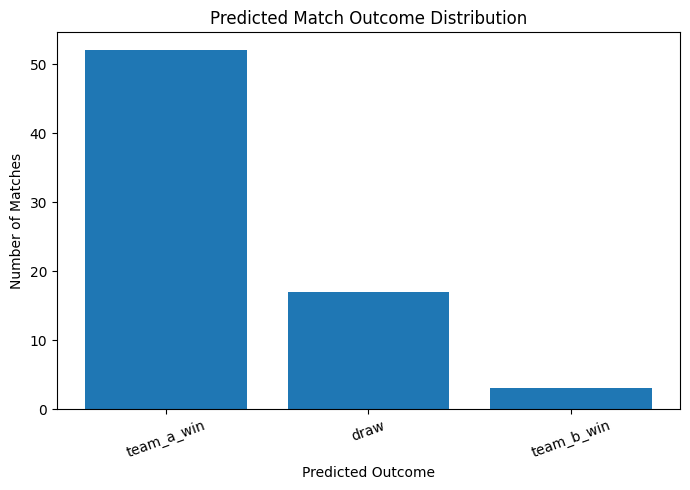

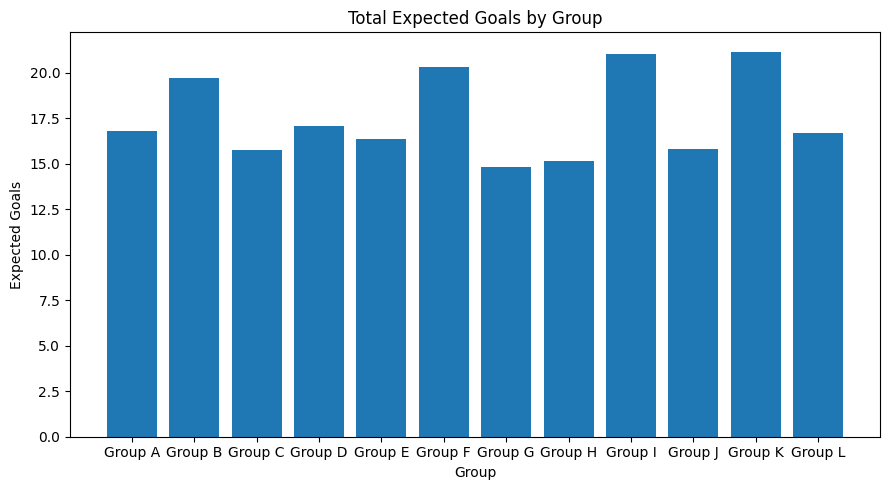

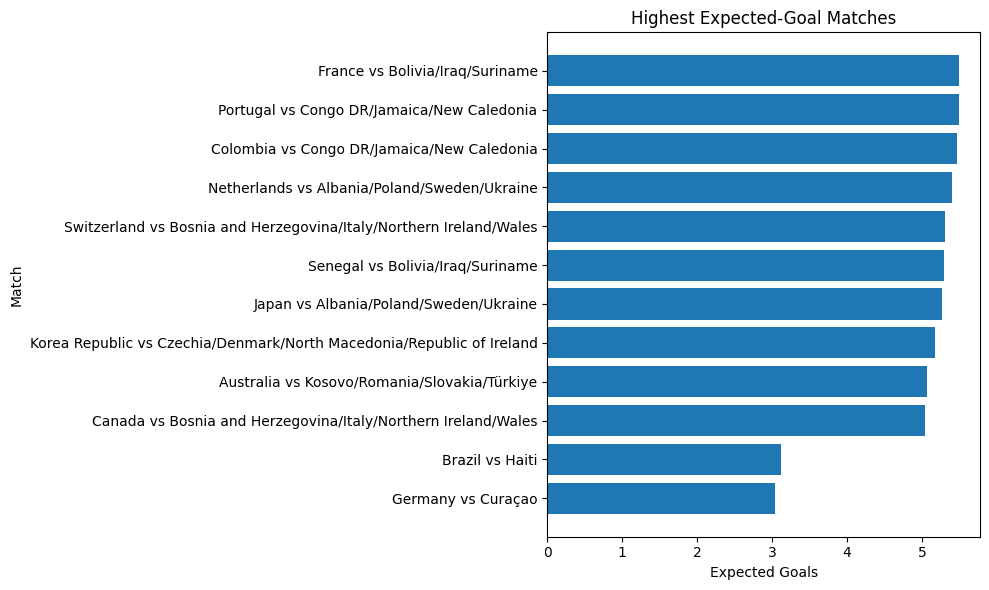

In [8]:
# 1) Predicted result distribution
result_counts = worldcup_predictions["final_predicted_result"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(result_counts.index, result_counts.values)
ax.set_title("Predicted Match Outcome Distribution")
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Number of Matches")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_predicted_result_distribution.png", dpi=150)
plt.show()

# 2) Expected goals by group
goals_by_group = worldcup_predictions.groupby("group")[
    ["predicted_team_a_goals", "predicted_team_b_goals"]
].sum()
goals_by_group["total_expected_goals"] = (
    goals_by_group["predicted_team_a_goals"] + goals_by_group["predicted_team_b_goals"]
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(goals_by_group.index, goals_by_group["total_expected_goals"])
ax.set_title("Total Expected Goals by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Expected Goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_expected_goals_by_group.png", dpi=150)
plt.show()

# 3) Highest predicted scoring matches
top_scoring = worldcup_predictions.copy()
top_scoring["total_expected_goals"] = (
    top_scoring["predicted_team_a_goals"] + top_scoring["predicted_team_b_goals"]
)
top_scoring["match"] = top_scoring["team_a"] + " vs " + top_scoring["team_b"]
top_scoring = top_scoring.sort_values("total_expected_goals", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_scoring["match"][::-1], top_scoring["total_expected_goals"][::-1])
ax.set_title("Highest Expected-Goal Matches")
ax.set_xlabel("Expected Goals")
ax.set_ylabel("Match")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_highest_expected_goal_matches.png", dpi=150)
plt.show()


## Group Table Simulation

Predicted scores are converted into group standings.

In [9]:
def initialize_team_row(team, group):
    return {
        "group": group,
        "team": team,
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "goals_for": 0,
        "goals_against": 0,
        "goal_difference": 0,
        "points": 0,
    }


standings = {}

for _, row in worldcup_predictions.iterrows():
    group = row["group"]
    team_a = row["team_a"]
    team_b = row["team_b"]
    goals_a = int(row["predicted_team_a_goals_rounded"])
    goals_b = int(row["predicted_team_b_goals_rounded"])

    if team_a not in standings:
        standings[team_a] = initialize_team_row(team_a, group)
    if team_b not in standings:
        standings[team_b] = initialize_team_row(team_b, group)

    standings[team_a]["played"] += 1
    standings[team_b]["played"] += 1

    standings[team_a]["goals_for"] += goals_a
    standings[team_a]["goals_against"] += goals_b

    standings[team_b]["goals_for"] += goals_b
    standings[team_b]["goals_against"] += goals_a

    if goals_a > goals_b:
        standings[team_a]["wins"] += 1
        standings[team_b]["losses"] += 1
        standings[team_a]["points"] += 3
    elif goals_a < goals_b:
        standings[team_b]["wins"] += 1
        standings[team_a]["losses"] += 1
        standings[team_b]["points"] += 3
    else:
        standings[team_a]["draws"] += 1
        standings[team_b]["draws"] += 1
        standings[team_a]["points"] += 1
        standings[team_b]["points"] += 1

standings_df = pd.DataFrame(list(standings.values()))
standings_df["goal_difference"] = standings_df["goals_for"] - standings_df["goals_against"]

standings_df = standings_df.sort_values(
    ["group", "points", "goal_difference", "goals_for"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

standings_df["group_rank"] = standings_df.groupby("group").cumcount() + 1

display(standings_df)

standings_df.to_csv(PREDICTIONS_DIR / "worldcup2026_predicted_group_standings.csv", index=False)
standings_df.to_csv(TABLES_DIR / "worldcup2026_predicted_group_standings.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_predicted_group_standings.csv")
print("Saved:", TABLES_DIR / "worldcup2026_predicted_group_standings.csv")


,group,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank
0,Group A,Mexico,3,3,0,0,6,1,5,9,1
1,Group A,South Africa,3,1,1,1,4,4,0,4,2
2,Group A,Korea Republic,3,1,0,2,6,4,2,3,3
3,Group A,Czechia/Denmark/North Macedonia/Republic of Ir...,3,0,1,2,1,8,-7,1,4
4,Group B,Switzerland,3,2,1,0,8,2,6,7,1
5,Group B,Canada,3,2,0,1,8,2,6,6,2
6,Group B,Qatar,3,0,2,1,2,4,-2,2,3
7,Group B,Bosnia and Herzegovina/Italy/Northern Ireland/...,3,0,1,2,1,11,-10,1,4
8,Group C,Brazil,3,2,0,1,6,3,3,6,1
9,Group C,Morocco,3,1,1,1,4,3,1,4,2


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_predicted_group_standings.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\worldcup2026_predicted_group_standings.csv


## Group Stage Validation

The prediction output is checked to confirm that only group-stage matches and teams are included.

In [10]:
print("Group match predictions:", worldcup_predictions.shape[0])
print("Predicted standings rows:", standings_df.shape[0])
print("Number of unique teams in standings:", standings_df["team"].nunique())
print("Number of groups:", standings_df["group"].nunique())

display(worldcup_predictions["group"].value_counts().sort_index().to_frame("matches"))
display(standings_df.groupby("group").size().to_frame("teams"))

if worldcup_predictions.shape[0] == 72 and standings_df.shape[0] == 48:
    print("Validation passed: 72 group matches and 48 group-stage teams.")
else:
    print("Validation warning: please check fixture filtering or group-stage input data.")


Group match predictions: 72
Predicted standings rows: 48
Number of unique teams in standings: 48
Number of groups: 12


,matches
group,
Group A,6
Group B,6
Group C,6
Group D,6
Group E,6
Group F,6
Group G,6
Group H,6
Group I,6


,teams
group,
Group A,4
Group B,4
Group C,4
Group D,4
Group E,4
Group F,4
Group G,4
Group H,4
Group I,4


Validation passed: 72 group matches and 48 group-stage teams.


## Group Standings Visualization

Predicted group points are shown as bar charts for presentation.

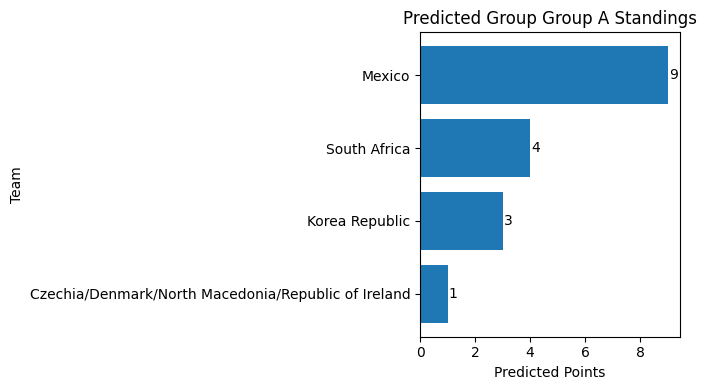

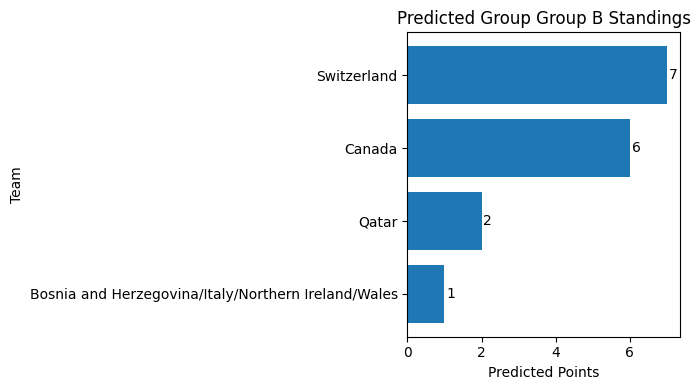

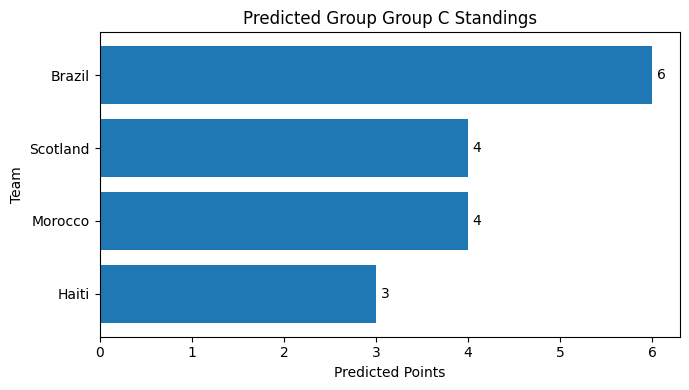

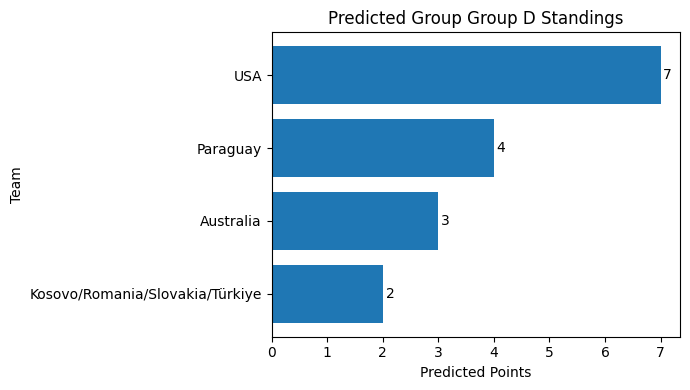

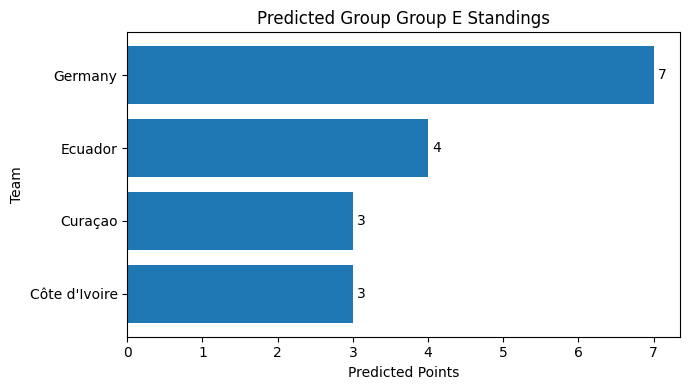

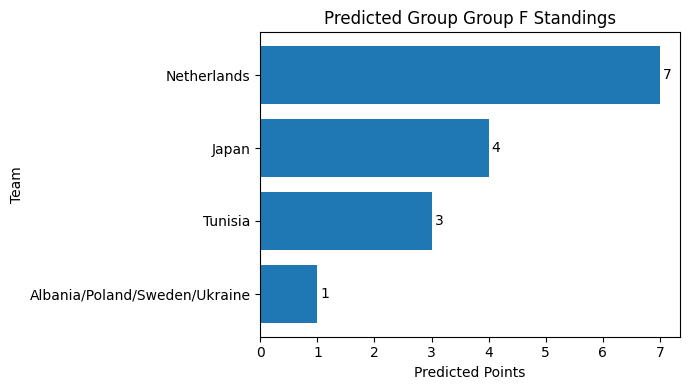

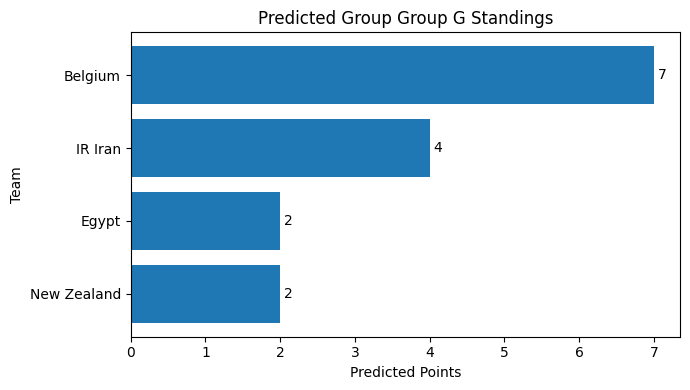

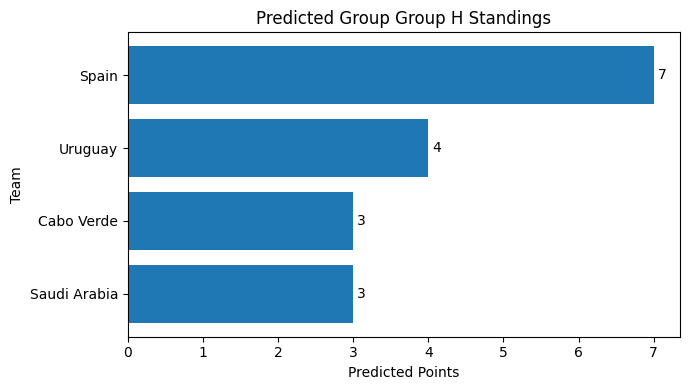

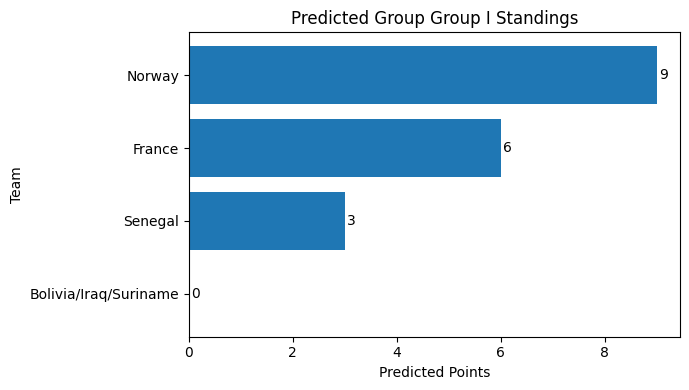

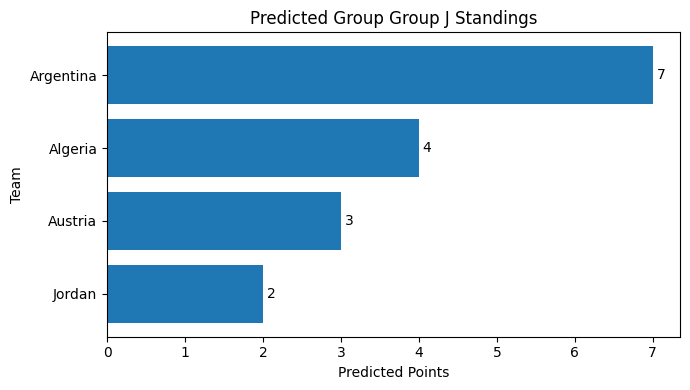

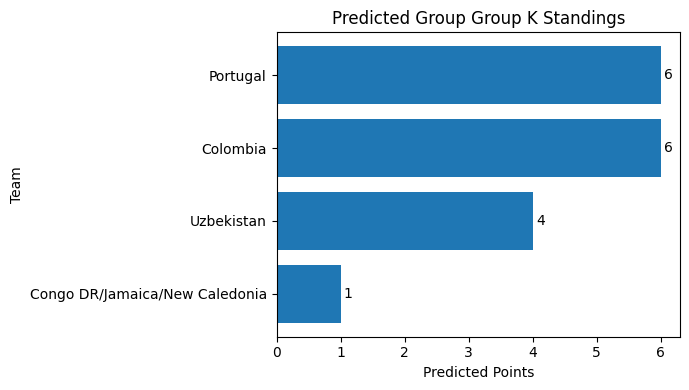

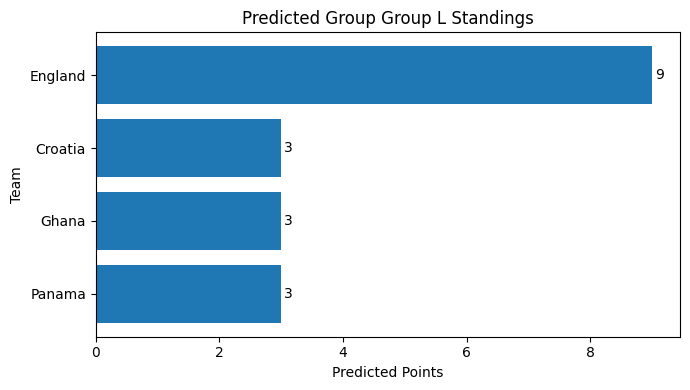

In [11]:
for group, group_df in standings_df.groupby("group"):
    group_plot = group_df.sort_values("points", ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(group_plot["team"], group_plot["points"])
    ax.set_title(f"Predicted Group {group} Standings")
    ax.set_xlabel("Predicted Points")
    ax.set_ylabel("Team")

    for i, value in enumerate(group_plot["points"]):
        ax.text(value + 0.05, i, str(value), va="center")

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"wc2026_group_{group}_predicted_points.png", dpi=150)
    plt.show()


## Predicted Qualified Teams

The top two teams from each group are selected as direct qualifiers for the next stage.

In [12]:
qualified_top2 = standings_df[standings_df["group_rank"] <= 2].copy()
qualified_top2 = qualified_top2.sort_values(["group", "group_rank"]).reset_index(drop=True)

display(qualified_top2[[
    "group", "group_rank", "team", "points", "goal_difference", "goals_for", "goals_against"
]])

qualified_top2.to_csv(PREDICTIONS_DIR / "worldcup2026_predicted_top2_qualified.csv", index=False)
qualified_top2.to_csv(TABLES_DIR / "worldcup2026_predicted_top2_qualified.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_predicted_top2_qualified.csv")
print("Saved:", TABLES_DIR / "worldcup2026_predicted_top2_qualified.csv")


,group,group_rank,team,points,goal_difference,goals_for,goals_against
0,Group A,1,Mexico,9,5,6,1
1,Group A,2,South Africa,4,0,4,4
2,Group B,1,Switzerland,7,6,8,2
3,Group B,2,Canada,6,6,8,2
4,Group C,1,Brazil,6,3,6,3
5,Group C,2,Morocco,4,1,4,3
6,Group D,1,USA,7,2,5,3
7,Group D,2,Paraguay,4,0,4,4
8,Group E,1,Germany,7,2,5,3
9,Group E,2,Ecuador,4,0,4,4


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_predicted_top2_qualified.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\worldcup2026_predicted_top2_qualified.csv


## Best Third-Place Candidates

The best third-place teams are ranked as additional qualification candidates.

In [13]:
third_place = standings_df[standings_df["group_rank"] == 3].copy()
third_place = third_place.sort_values(
    ["points", "goal_difference", "goals_for"],
    ascending=[False, False, False]
).reset_index(drop=True)

third_place["third_place_rank"] = third_place.index + 1

display(third_place[[
    "third_place_rank", "group", "team", "points", "goal_difference", "goals_for", "goals_against"
]])

third_place.to_csv(PREDICTIONS_DIR / "worldcup2026_predicted_third_place_ranking.csv", index=False)
third_place.to_csv(TABLES_DIR / "worldcup2026_predicted_third_place_ranking.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "worldcup2026_predicted_third_place_ranking.csv")
print("Saved:", TABLES_DIR / "worldcup2026_predicted_third_place_ranking.csv")


,third_place_rank,group,team,points,goal_difference,goals_for,goals_against
0,1,Group C,Scotland,4,0,4,4
1,2,Group K,Uzbekistan,4,0,4,4
2,3,Group D,Australia,3,3,7,4
3,4,Group I,Senegal,3,3,7,4
4,5,Group A,Korea Republic,3,2,6,4
5,6,Group J,Austria,3,1,5,4
6,7,Group F,Tunisia,3,0,3,3
7,8,Group E,Curaçao,3,-1,4,5
8,9,Group H,Cabo Verde,3,-1,4,5
9,10,Group L,Ghana,3,-2,3,5


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\worldcup2026_predicted_third_place_ranking.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\worldcup2026_predicted_third_place_ranking.csv


## Third-Place Candidate Visualization

Third-place candidates are compared by predicted points and goal difference.

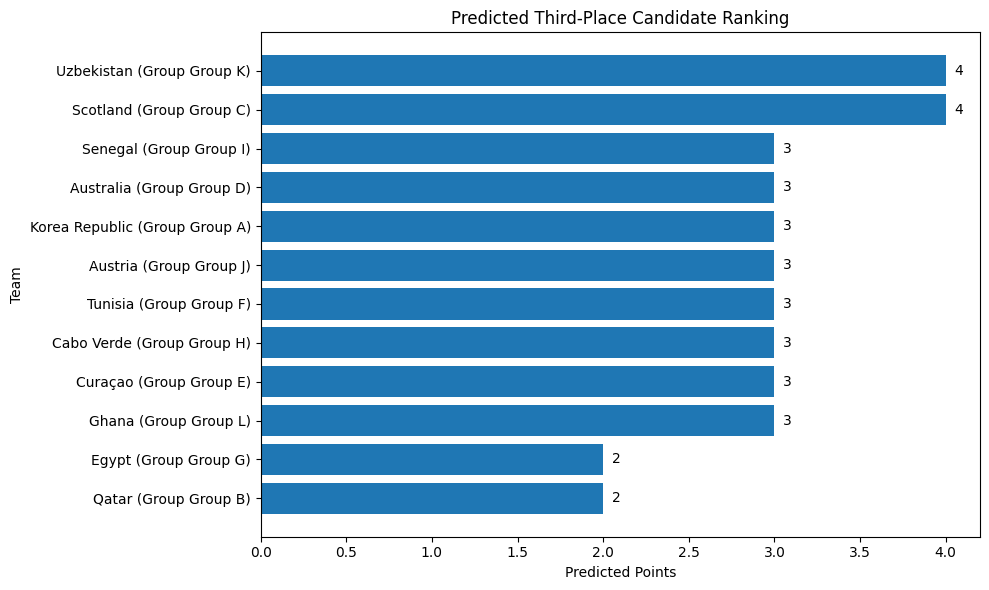

In [14]:
third_plot = third_place.sort_values(["points", "goal_difference"], ascending=True)
third_plot["label"] = third_plot["team"] + " (Group " + third_plot["group"].astype(str) + ")"

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(third_plot["label"], third_plot["points"])
ax.set_title("Predicted Third-Place Candidate Ranking")
ax.set_xlabel("Predicted Points")
ax.set_ylabel("Team")

for i, value in enumerate(third_plot["points"]):
    ax.text(value + 0.05, i, str(value), va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "wc2026_third_place_candidates.png", dpi=150)
plt.show()


## Final Output Overview

The group-stage predictions, standings, qualifiers, and figures are saved for the next project step.

In [15]:
print("Prediction files:")
print(" - output/predictions/worldcup2026_group_match_predictions.csv")
print(" - output/predictions/worldcup2026_predicted_group_standings.csv")
print(" - output/predictions/worldcup2026_predicted_top2_qualified.csv")
print(" - output/predictions/worldcup2026_predicted_third_place_ranking.csv")

print("\nTable files:")
print(" - output/tables/worldcup2026_group_match_predictions.csv")
print(" - output/tables/worldcup2026_predicted_group_standings.csv")
print(" - output/tables/worldcup2026_predicted_top2_qualified.csv")
print(" - output/tables/worldcup2026_predicted_third_place_ranking.csv")

print("\nFigure files:")
print(" - output/figures/wc2026_predicted_result_distribution.png")
print(" - output/figures/wc2026_expected_goals_by_group.png")
print(" - output/figures/wc2026_highest_expected_goal_matches.png")
print(" - output/figures/wc2026_group_<GROUP>_predicted_points.png")
print(" - output/figures/wc2026_third_place_candidates.png")

print("\nWorld Cup 2026 group prediction completed.")


Prediction files:
 - output/predictions/worldcup2026_group_match_predictions.csv
 - output/predictions/worldcup2026_predicted_group_standings.csv
 - output/predictions/worldcup2026_predicted_top2_qualified.csv
 - output/predictions/worldcup2026_predicted_third_place_ranking.csv

Table files:
 - output/tables/worldcup2026_group_match_predictions.csv
 - output/tables/worldcup2026_predicted_group_standings.csv
 - output/tables/worldcup2026_predicted_top2_qualified.csv
 - output/tables/worldcup2026_predicted_third_place_ranking.csv

Figure files:
 - output/figures/wc2026_predicted_result_distribution.png
 - output/figures/wc2026_expected_goals_by_group.png
 - output/figures/wc2026_highest_expected_goal_matches.png
 - output/figures/wc2026_group_<GROUP>_predicted_points.png
 - output/figures/wc2026_third_place_candidates.png

World Cup 2026 group prediction completed.
